# DML & 401K Contributions

Double/Debiased machine learning (DML) is a framework for estimating treatment effects using any machine learning method. Where the meta-learners framework is about using plug-and-play estimators to estimate treatment effects, DML brings some science, recognising that arbitrarily applying ML techniques to estimate treatment effects introduces a source of non-trivial bias.  

In this notebook I first discuss the theory behind DML, demonstrating how bias arises from arbitrary application of ML and how 'partialling-out' is DML's approach to removing this bias. Then I will apply these techniques to a real dataset. I will use DML to estimate the impact 401K eligibility on net financial assets - clearly a causal inference question as eligibility and enrollment into a 401K and net financial assets are confounded by, among other things, attitudes towards savings. After some EDA on the dataset and proper framing of the problem I...

## Theory behind DML

**Note that PLM is one model - generic DML covers interactive models and fully heterogenous models**

### Problem Framing

Consider the following partially linear model (PLM),

$$
y = \theta d + g(X) + \epsilon
$$
$$
D = m(X) + v
$$

Where $d$ is the vector of treatment values, $X$ is some high dimensional vector of other features or controls and $\theta$ is the causal effect of interest. The second equation shows that the treatment and the outcome are possibly confounded by $X$. It is assumed that $E[\epsilon | X, d] = 0$. In DML we call the $g(X)$ and $m(X)$ the nuisance parameters. They are a nuisance because accurate estimation of these function is what stands between us and a correct estimate of $\theta$.

### Naive Estimation

The naive method is to simply plug in a ML method to estimate $g(X)$. If we know this function then we have,

$$
y - g(X) = \theta d + \epsilon
$$

This is a regression of $y - g(X)$ on $d$ and the OLS solution is

$$
\hat{\theta} = \left(\frac{1}{n}\sum{d_{i}^{2}}\right) \frac{1}{n}\sum{D_{i}(y_{i} - g(X))}
$$

Since $g(X)$ is unknown we estimate it with an ML method for $\hat{g}(x)$ and plug this into the formula. However we have a problem $g(X)$ depends on $\theta$.

$$
g(X) = E[y - \theta d | X]
$$

We can take a guess at theta and create the target $y - \theta d$ then fit $g(X)$ plug this into the formula and recalulate $\theta$ and repeat until $\theta$ stops changing. Or we can be even more naive and just estimate 

$$
g(X) = E[y | X]
$$

However, there is an asymptopic bias in estimating theta this way! This emerges from the regularisation bias of ML methods. Regularisation is required to stop ML methods overfitting, however this also means that

$$
E[g(X) - \hat{g}(X)] \ne 0
$$

**and this matters because we need to use g(X) to create the tagret for the regression to estimate $\theta$**

An intuitive way to understand this is if we consider the LASSO. The lasso shrinks some coefficients to 0 and therefore may remove the influence of confounders (the exact influence we want to control for). To understand how DML tries to solve this problem we first need to understand the Frisch Waugh Lovell Theorem

### Frisch Waugh Lovell Theorem

The Frisch, Waugh, Lovell were 20th Century econometricians who showed that a estimation of a parameter in a regression problem is equivalent to the partialling out of all other terms in the problem and then running another regression on the partialled out values of the outcome and the features of interest. For example take the regression equation

$$
y = \beta_{1}X_{1} + \beta_{2}X_{2} + \epsilon
$$

The Frisch Waugh Lovell Theorem (FWL) is that you can estimate the $\beta_{1}$ parameter with the following procedure

1. Obtain the fitted values $\hat{y}^{*}$ with the regression $\hat{y}^{*} = \gamma_{1}X_{2}$
2. Obtain the fitted values $\hat{X}$ with the regression $\hat{X} = \gamma_{2}X_{2}$
3. Obtain the residuals $\tilde{X}_1 = X_1 - \hat{X_1}$ and $\tilde{y} = y - \hat{y}^{*}$
4. Regress the residuals of the outcomes on the residuals of the features $\tilde{y} = \beta_{1}\tilde{X}_1$

The first step removes all the variation in $y$ associated with $X_{2}$ the second step does the same for the variation in $X_{1}$ then finally we can estimate the parameter of interest free of any influence from the nuisance parameters! We say the $y$ and $X_{1}$ have been debiased with respect to $X_{2}$


### DML

DML essentially applies the FWL when using ML methods to estimate functions. Chernozhukov (2018) showed that you can do orthogonalise (debias) data with machine learning. So going back to our original problem above we get

$$
\tilde{y}_{i} = y_{i} - \hat{g}(X_{i})  
$$
$$
\tilde{d}_{i} = d_{i} - \hat{m}(X_{i})  
$$

**and then we regress these**

**overfitting**

In [1]:
# Imports
from get_data import fetch_401k_data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import scipy.stats as stats

## Simulated Example

To clearly show the bias in the naive estimation method I first show a simulated example. We have the following model,

$$
y = 2.5x_{1} + log(x_{2}^{2}) + \epsilon
$$
$$
x_{1} = e^{x_{2}}/4 + U
$$
$$
\epsilon, U, x_{2} \sim N(0, 1)
$$
$$
\theta = 2.5
$$

To estimate $\theta$, I use the more naive method and simply estimate $g(x_{2}) = E[y| x_{2}]$. Once estimated we create the new target which is the residuals $y - \hat{g}(x2)$ and finally we fit a linear regression model to this new target with x1 as the regressor. We normalise the $\theta\text{s}$ and plot the histogram of estimates. We can see there is a large bias

In [40]:
n, reps, theta0 = 1000, 1000, 0.5

thetas = []
ses = []

for _ in range(reps):
    x2 = np.random.normal(size=n)
    x1 = np.exp(x2)/4 + np.random.normal(size=n)
    y = theta0*x1 + np.log(x2**2) + np.random.normal(size=n)

    train_x1, test_x1, train_x2, test_x2, train_y, test_y = train_test_split(x1, x2, y, test_size=0.5)

    # Estimate g(x2)
    g_model = RandomForestRegressor(n_estimators=10, max_depth=5)
    g_model.fit(train_x2.reshape(-1, 1), train_y)

    # Create residuals for y
    y_residuals = test_y - g_model.predict(test_x2.reshape(-1, 1))

    # Estimate theta
    theta_model = LinearRegression(fit_intercept=False)
    theta_model.fit(test_x1.reshape(-1, 1), y_residuals)
    theta_hat = theta_model.coef_[0]

    # Estimate standard error
    m   = len(test_x1)
    psi = test_x1 * (y_residuals - theta_hat * test_x1)
    J   = np.mean(test_x1**2)
    se  = np.sqrt(np.mean(psi**2) / m) / J

    thetas.append(theta_hat)
    ses.append(se)

In [41]:
normalised_thetas = (np.array(thetas) - theta0) / np.array(ses)

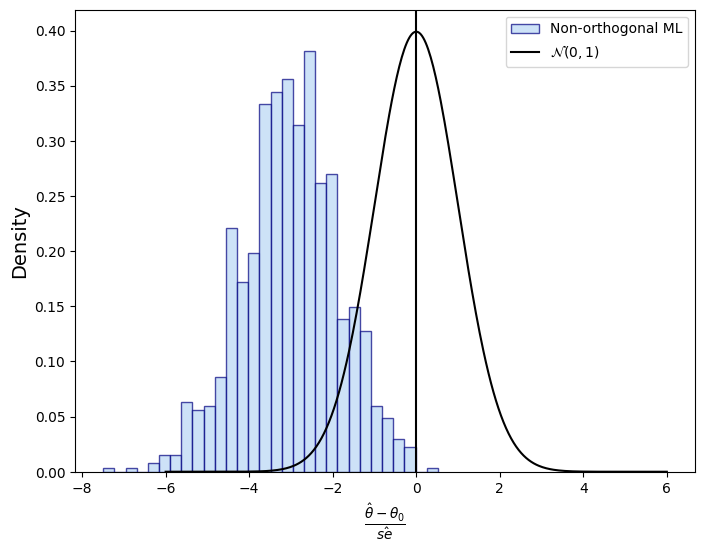

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(normalised_thetas, bins=30, density=True, alpha=0.7,
        color='#b9d7f5', edgecolor='navy', label='Non-orthogonal ML')

grid = np.linspace(-6, 6, 400)
ax.plot(grid, stats.norm.pdf(grid), 'k', label=r'$\mathcal{N}(0,1)$')
ax.axvline(0, color='k')
ax.set_xlabel(r'$\frac{\hat{\theta} - \theta_0}{\hat{se}}$', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.legend()

Now we use DML to estimate the causal parameter. 

In [49]:
n, reps, theta0 = 1000, 1000, 0.5

thetas = []
ses = []

for _ in range(reps):
    x2 = np.random.normal(size=n)
    x1 = np.exp(x2)/4 + np.random.normal(size=n)
    y = theta0*x1 + np.log(x2**2) + np.random.normal(size=n)

    train_x1, test_x1, train_x2, test_x2, train_y, test_y = train_test_split(x1, x2, y, test_size=0.5)

    # Estimate g(x2)
    g_model = RandomForestRegressor(n_estimators=50, max_depth=5)
    g_model.fit(train_x2.reshape(-1, 1), train_y)

    # estimatre m(x2)
    m_model = RandomForestRegressor(n_estimators=50, max_depth=5)
    m_model.fit(train_x2.reshape(-1, 1), train_x1)

    # Create residuals
    y_residuals = test_y - g_model.predict(test_x2.reshape(-1, 1))
    x1_residuals = test_x1 - m_model.predict(test_x2.reshape(-1, 1))

    # Estimate theta
    theta_model = LinearRegression(fit_intercept=False)
    theta_model.fit(x1_residuals.reshape(-1, 1), y_residuals)
    theta_hat = theta_model.coef_[0]

    # Estimate standard error
    m   = len(x1_residuals)
    psi = x1_residuals * (y_residuals - theta_hat * x1_residuals)
    J   = np.mean(x1_residuals**2)
    se  = np.sqrt(np.mean(psi**2) / m) / J

    thetas.append(theta_hat)
    ses.append(se)

In [50]:
normalised_thetas = (np.array(thetas) - theta0) / np.array(ses)

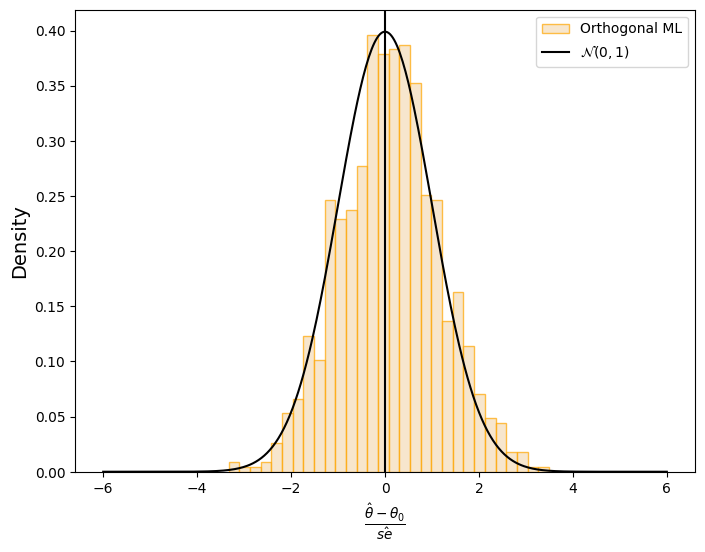

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(normalised_thetas, bins=30, density=True, alpha=0.7,
        color="#f5dcb9", edgecolor='orange', label='Orthogonal ML')

grid = np.linspace(-6, 6, 400)
ax.plot(grid, stats.norm.pdf(grid), 'k', label=r'$\mathcal{N}(0,1)$')
ax.axvline(0, color='k')
ax.set_xlabel(r'$\frac{\hat{\theta} - \theta_0}{\hat{se}}$', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.legend()

## Load Data

- explain dataset

In [2]:
# Data
df = fetch_401k_data()
df.head()

,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [ ]:
# EDA

## DML Modelling

In [ ]:
# DML

## Bibliography

Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018). Double/debiased machine learning for treatment and structural parameters. *The Econometrics Journal*, 21(1), C1-C68. https://doi.org/10.1111/ectj.12097 (arXiv:1608.00060)

Chernozhukov, V., Hansen, C., Kallus, N., Spindler, M., & Syrgkanis, V. (2024). *Applied Causal Inference Powered by ML and AI*. arXiv:2403.02467. https://causalml-book.org

Facure, M. (2022). *Causal Inference for the Brave and True*. https://matheusfacure.github.io/python-causality-handbook/

DoubleML Developers. (n.d.). *DoubleML: Basics, data-generating process*. Retrieved 5 October 2026, from https://docs.doubleml.org/stable/guide/basics.html#data-generating-process

DoubleML Developers. (n.d.). *Python: Impact of 401(k) eligibility on financial wealth*. Retrieved 5 October 2026, from https://docs.doubleml.org/stable/examples/py_double_ml_pension.html

Robinson, P. M. (1988). Root-N-consistent semiparametric regression. *Econometrica*, 56(4), 931-954. https://doi.org/10.2307/1912705